<a href="https://colab.research.google.com/github/Athenimadhu/Air-Quality-PM2.5-Forecasting-Using-Machine-Learning/blob/main/project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
np.random.seed(42)

os.makedirs("figures", exist_ok=True)

def save_fig(name):
    plt.tight_layout()
    plt.savefig(f"figures/{name}.png", dpi=300, bbox_inches="tight")
    plt.show()

Load data

In [3]:
df = pd.read_csv("/content/processed_aqi_data.csv")

print("Dataset shape:", df.shape)
display(df.head())
df.info()

Dataset shape: (219125, 18)


,timestamp,location_name,location_lat,location_lon,co,no2,o3,pm10,pm25,so2,aqi,aqi_category,hour,day,month,year,day_of_week,is_weekend
0,2019-01-01 00:00:00,Delhi,28.7041,77.1025,0.598089,24.943655,18.081507,108.281832,75.196148,4.378213,221.629670,Poor,0,1,1,2019,1,0
1,2019-01-01 00:00:00,Faridabad,28.4089,77.3178,1.093698,5.699821,53.686134,56.260069,42.709284,6.493686,137.180953,Moderate,0,1,1,2019,1,0
2,2019-01-01 00:00:00,Ghaziabad,28.6692,77.4538,0.420770,19.419563,34.967340,82.842934,59.295449,4.423260,205.059468,Poor,0,1,1,2019,1,0
3,2019-01-01 00:00:00,Gurgaon,28.4595,77.0266,0.706815,30.585009,35.874847,117.015282,75.435553,7.511787,221.879156,Poor,0,1,1,2019,1,0
4,2019-01-01 00:00:00,Noida,28.5355,77.3910,0.542118,23.626271,39.401078,116.208836,68.843636,6.828320,215.009684,Poor,0,1,1,2019,1,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219125 entries, 0 to 219124
Data columns (total 18 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   timestamp      219125 non-null  object 
 1   location_name  219125 non-null  object 
 2   location_lat   219125 non-null  float64
 3   location_lon   219125 non-null  float64
 4   co             219125 non-null  float64
 5   no2            219125 non-null  float64
 6   o3             219125 non-null  float64
 7   pm10           219125 non-null  float64
 8   pm25           219125 non-null  float64
 9   so2            219125 non-null  float64
 10  aqi            219125 non-null  float64
 11  aqi_category   219125 non-null  object 
 12  hour           219125 non-null  int64  
 13  day            219125 non-null  int64  
 14  month          219125 non-null  int64  
 15  year           219125 non-null  int64  
 16  day_of_week    219125 non-null  int64  
 17  is_weekend     219125 non-nul

Missing values and duplicates

In [4]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()
print("Shape after duplicate removal:", df.shape)

Missing values:
timestamp        0
location_name    0
location_lat     0
location_lon     0
co               0
no2              0
o3               0
pm10             0
pm25             0
so2              0
aqi              0
aqi_category     0
hour             0
day              0
month            0
year             0
day_of_week      0
is_weekend       0
dtype: int64

Duplicate rows: 0
Shape after duplicate removal: (219125, 18)


Convert timestamp

In [5]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values(["location_name", "timestamp"])

print(df["timestamp"].min())
print(df["timestamp"].max())

2019-01-01 00:00:00
2024-01-01 00:00:00


EDA graphs

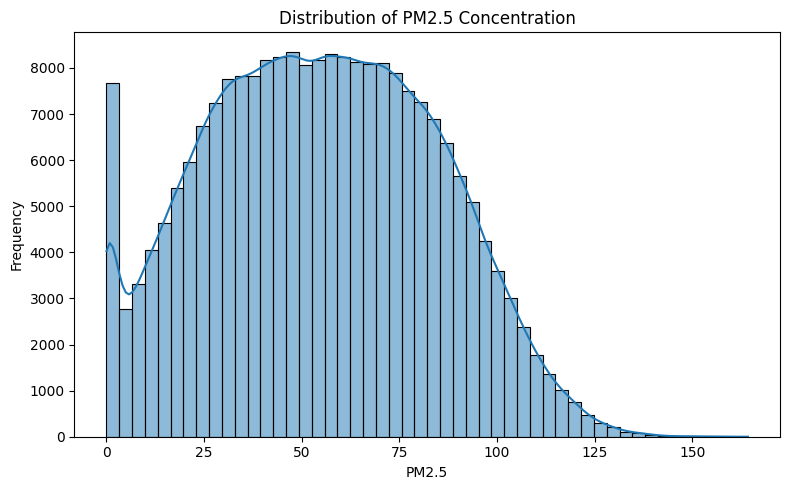

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df["pm25"], bins=50, kde=True)
plt.title("Distribution of PM2.5 Concentration")
plt.xlabel("PM2.5")
plt.ylabel("Frequency")
save_fig("pm25_distribution")

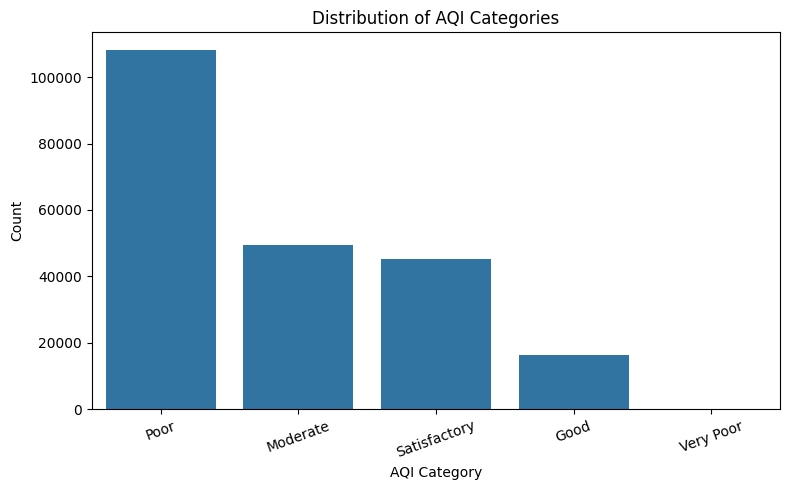

In [7]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="aqi_category", order=df["aqi_category"].value_counts().index)
plt.title("Distribution of AQI Categories")
plt.xlabel("AQI Category")
plt.ylabel("Count")
plt.xticks(rotation=20)
save_fig("aqi_category_distribution")

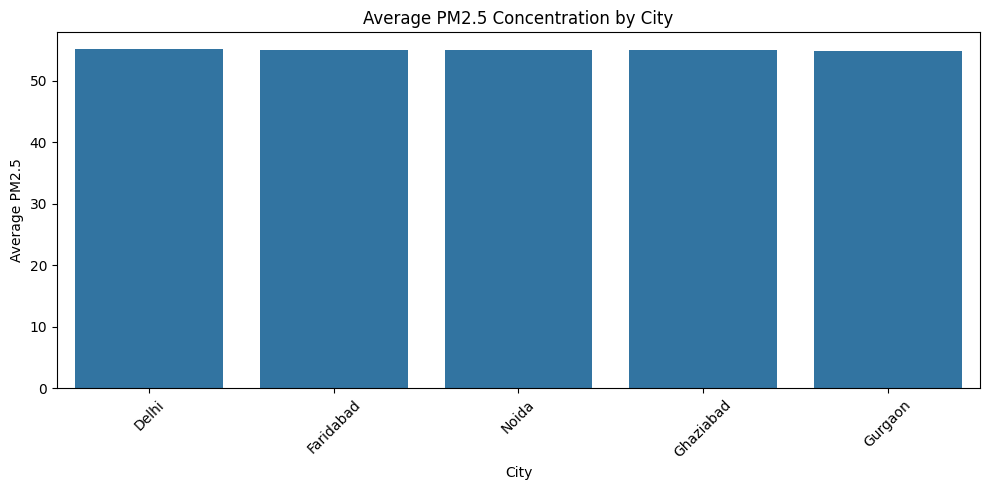

In [8]:
city_pm25 = df.groupby("location_name")["pm25"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=city_pm25.index, y=city_pm25.values)
plt.title("Average PM2.5 Concentration by City")
plt.xlabel("City")
plt.ylabel("Average PM2.5")
plt.xticks(rotation=45)
save_fig("average_pm25_by_city")

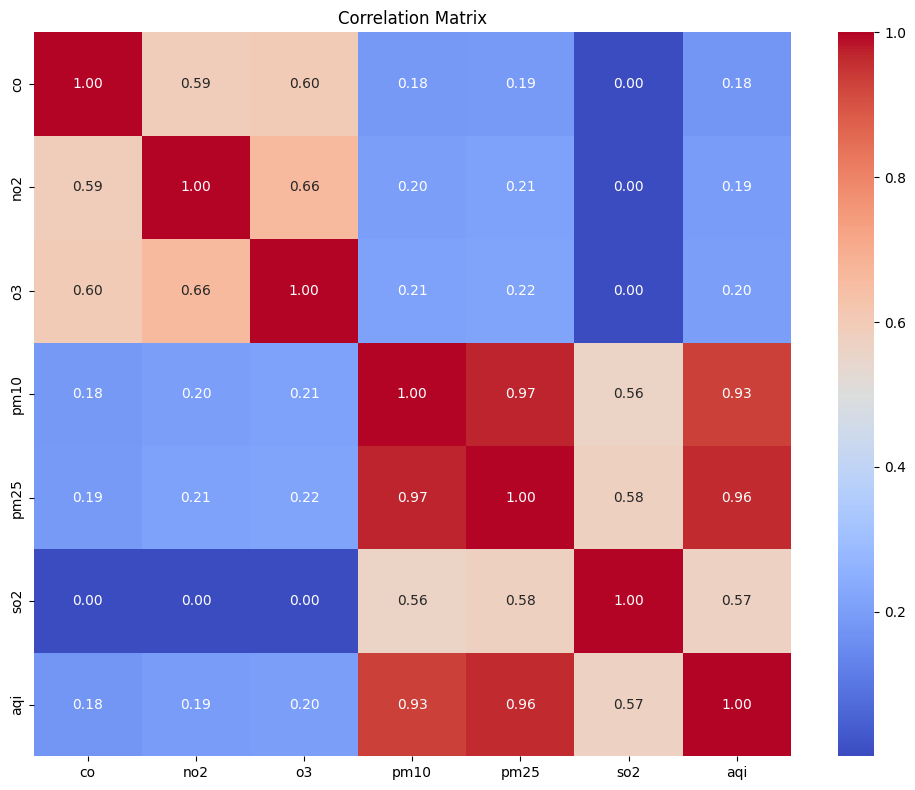

In [9]:
corr = df[["co", "no2", "o3", "pm10", "pm25", "so2", "aqi"]].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
save_fig("correlation_matrix")

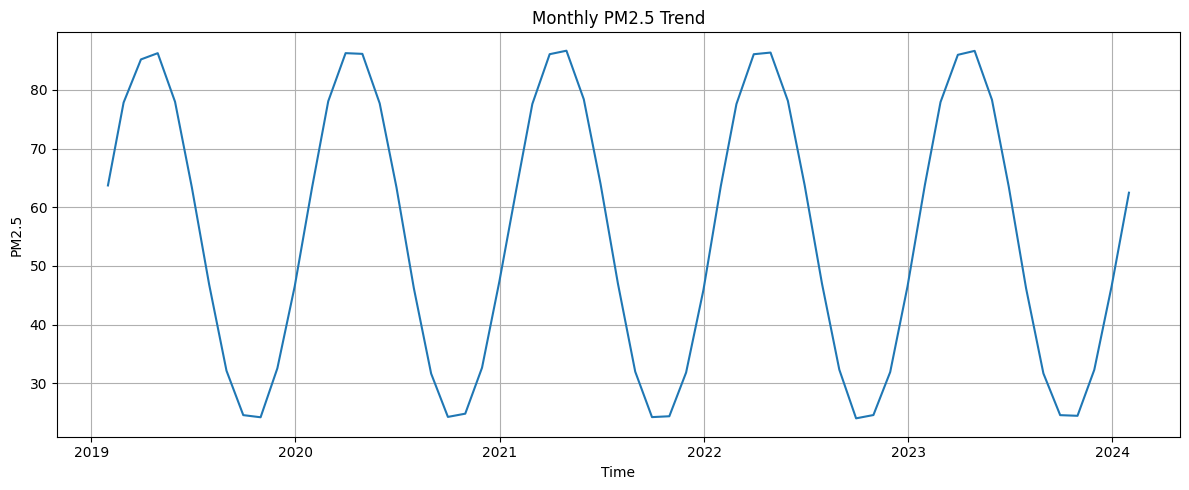

In [10]:
monthly_pm25 = df.set_index("timestamp")["pm25"].resample("M").mean()

plt.figure(figsize=(12,5))
plt.plot(monthly_pm25)
plt.title("Monthly PM2.5 Trend")
plt.xlabel("Time")
plt.ylabel("PM2.5")
plt.grid(True)
save_fig("monthly_pm25_trend")

Feature engineering

In [11]:
data = df.copy()

data["timestamp"] = pd.to_datetime(data["timestamp"])
data = data.sort_values(["location_name", "timestamp"])

data["day_of_year"] = data["timestamp"].dt.dayofyear
data["week_of_year"] = data["timestamp"].dt.isocalendar().week.astype(int)

data = data.drop(columns=["timestamp", "aqi", "aqi_category"])

for lag in [1, 3, 6, 12, 24]:
    data[f"pm25_lag_{lag}"] = data.groupby("location_name")["pm25"].shift(lag)

for window in [3, 6, 12, 24]:
    data[f"pm25_roll_{window}"] = (
        data.groupby("location_name")["pm25"]
        .rolling(window)
        .mean()
        .reset_index(level=0, drop=True)
    )

data = data.dropna()

data = pd.get_dummies(data, columns=["location_name"], drop_first=True)

print("Final modelling data shape:", data.shape)
display(data.head())

Final modelling data shape: (219005, 29)


,location_lat,location_lon,co,no2,o3,pm10,pm25,so2,hour,day,...,pm25_lag_12,pm25_lag_24,pm25_roll_3,pm25_roll_6,pm25_roll_12,pm25_roll_24,location_name_Faridabad,location_name_Ghaziabad,location_name_Gurgaon,location_name_Noida
120,28.7041,77.1025,0.840407,14.201873,18.171456,100.822210,72.206394,5.016605,0,2,...,85.027120,75.196148,59.522073,55.029260,55.107354,61.477838,False,False,False,False
125,28.7041,77.1025,0.914862,33.703721,52.881813,58.525557,42.517738,6.555451,1,2,...,74.885304,65.451836,55.101973,53.677506,52.410057,60.522251,False,False,False,False
130,28.7041,77.1025,1.066817,14.360735,51.991781,126.446245,72.801279,6.031865,2,2,...,57.564845,24.225843,62.508470,57.478561,53.679760,62.546227,False,False,False,False
135,28.7041,77.1025,0.514159,29.831061,40.391475,97.584316,62.040109,8.045935,3,2,...,64.212241,65.056997,59.119709,59.320891,53.498749,62.420524,False,False,False,False
140,28.7041,77.1025,1.039535,30.735546,69.698146,104.726657,73.660792,3.731785,4,2,...,37.601945,70.506701,69.500727,62.301350,56.503652,62.551944,False,False,False,False


Features and target

In [12]:
X = data.drop(columns=["pm25"])
y = data["pm25"]

split = int(len(data) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (175204, 28)
X_test: (43801, 28)
y_train: (175204,)
y_test: (43801,)


Evaluation function

In [13]:
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(model_name)
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R²  :", r2)
    print("-" * 35)

    return rmse, mae, r2

Train models

In [14]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_results = evaluate_model(y_test, lr_pred, "Linear Regression")

Linear Regression
RMSE: 6.120528527428183
MAE : 4.881852552629821
R²  : 0.9556476309911648
-----------------------------------


In [15]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_results = evaluate_model(y_test, rf_pred, "Random Forest")

Random Forest
RMSE: 6.216689824822718
MAE : 4.943309985693895
R²  : 0.9542430184740404
-----------------------------------


In [16]:
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_results = evaluate_model(y_test, gb_pred, "Gradient Boosting")

Gradient Boosting
RMSE: 6.13108114350434
MAE : 4.881267303089036
R²  : 0.9554945602239737
-----------------------------------


Model comparison table and graphs

In [17]:
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "RMSE": [lr_results[0], rf_results[0], gb_results[0]],
    "MAE": [lr_results[1], rf_results[1], gb_results[1]],
    "R2": [lr_results[2], rf_results[2], gb_results[2]]
})

display(results_df)
results_df.to_csv("model_comparison_results.csv", index=False)

,Model,RMSE,MAE,R2
0,Linear Regression,6.120529,4.881853,0.955648
1,Random Forest,6.216690,4.943310,0.954243
2,Gradient Boosting,6.131081,4.881267,0.955495


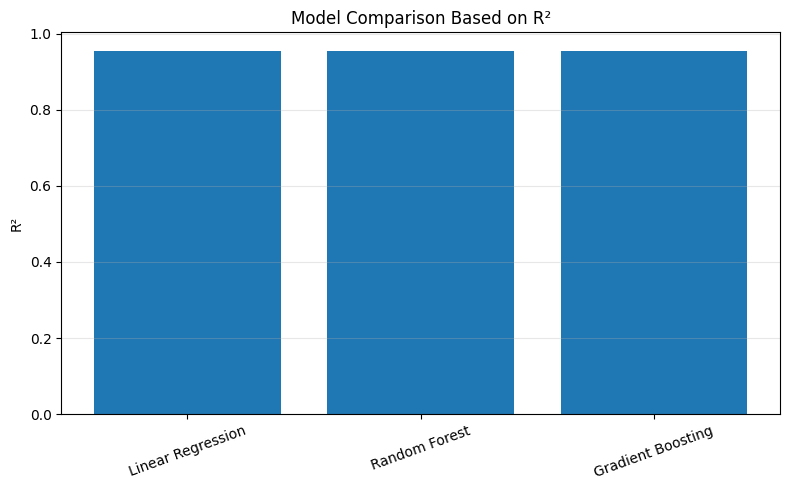

In [18]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["R2"])
plt.title("Model Comparison Based on R²")
plt.ylabel("R²")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
save_fig("model_comparison_r2")

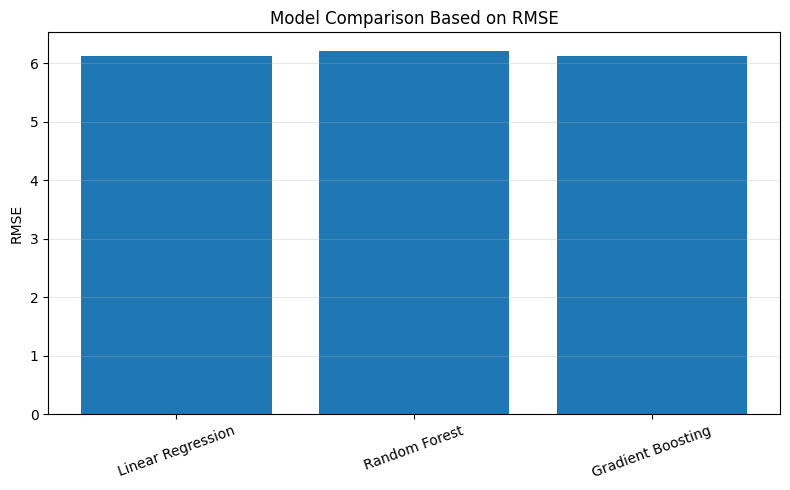

In [19]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Model Comparison Based on RMSE")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
save_fig("model_comparison_rmse")

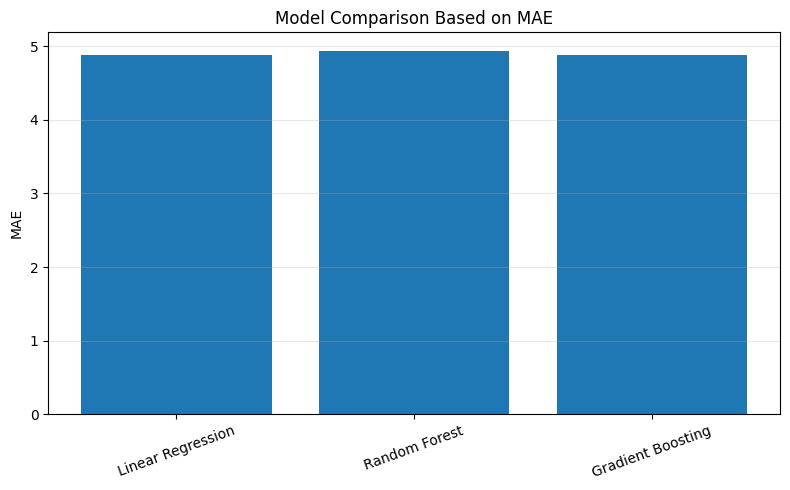

In [20]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["MAE"])
plt.title("Model Comparison Based on MAE")
plt.ylabel("MAE")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
save_fig("model_comparison_mae")

Actual vs predicted

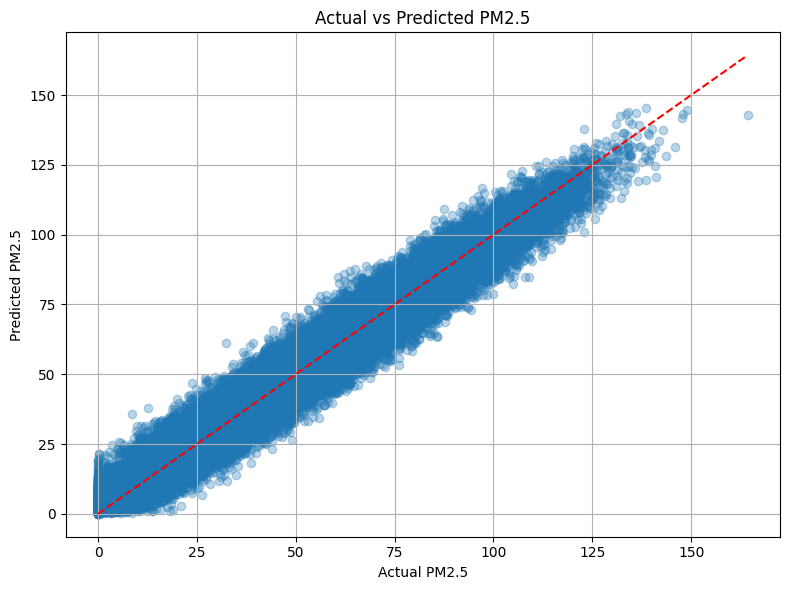

In [21]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, rf_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Actual vs Predicted PM2.5")
plt.grid(True)
save_fig("actual_vs_predicted_pm25")

Feature importance

,Feature,Importance
5,pm10,0.947769
20,pm25_roll_3,0.016233
15,pm25_lag_1,0.005338
19,pm25_lag_24,0.002277
6,so2,0.002246
17,pm25_lag_6,0.002203
2,co,0.002136
16,pm25_lag_3,0.002128
18,pm25_lag_12,0.002077
4,o3,0.002065


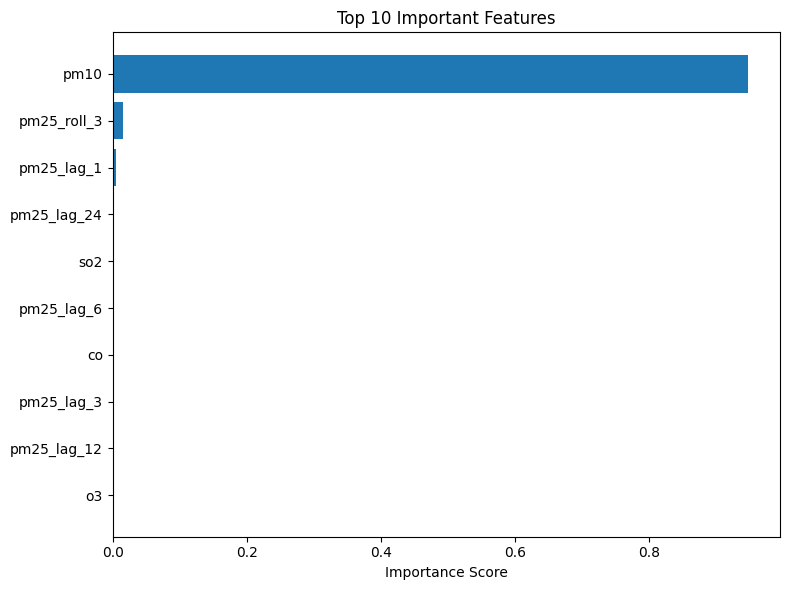

In [22]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False).head(10)

display(importance)

plt.figure(figsize=(8,6))
plt.barh(importance["Feature"], importance["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Top 10 Important Features")
save_fig("feature_importance_top10")

SHAP

In [23]:
!pip install shap -q

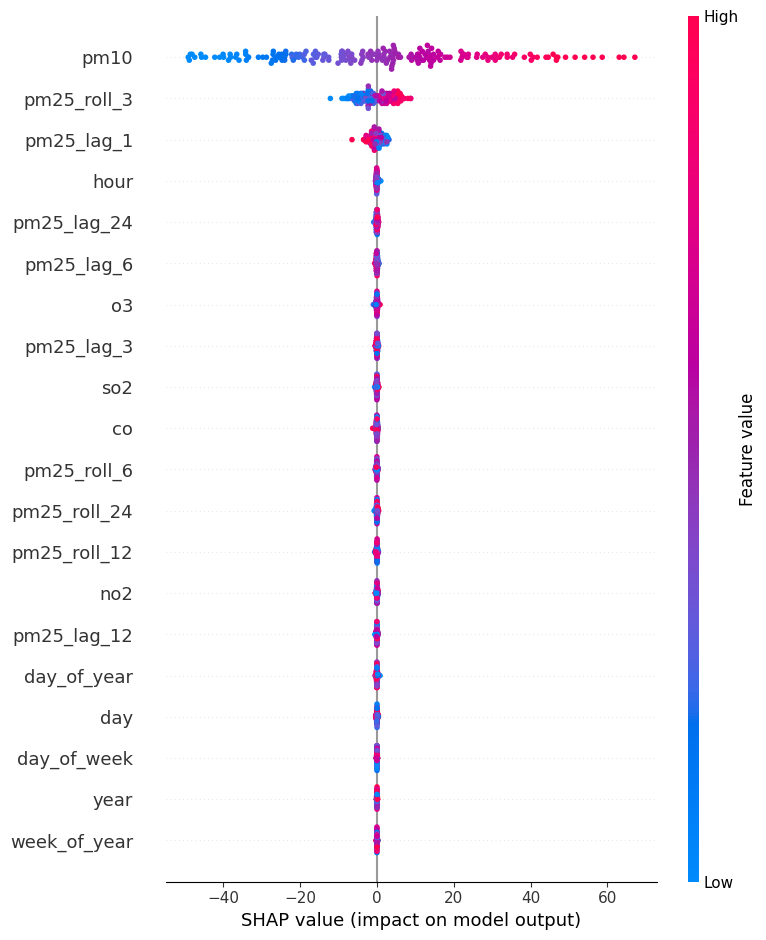

In [24]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# Take a smaller sample so Colab does not crash
X_shap = X_train.sample(n=200, random_state=42).astype(float)

# Convert all columns to numeric float
X_shap = X_shap.astype(float)

# Create SHAP explainer for Random Forest
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_shap)

# Plot SHAP summary
plt.figure()
shap.summary_plot(
    shap_values,
    X_shap,
    show=False
)

plt.savefig("figures/shap_summary_plot.png", dpi=300, bbox_inches="tight")
plt.show()

Residual analysis

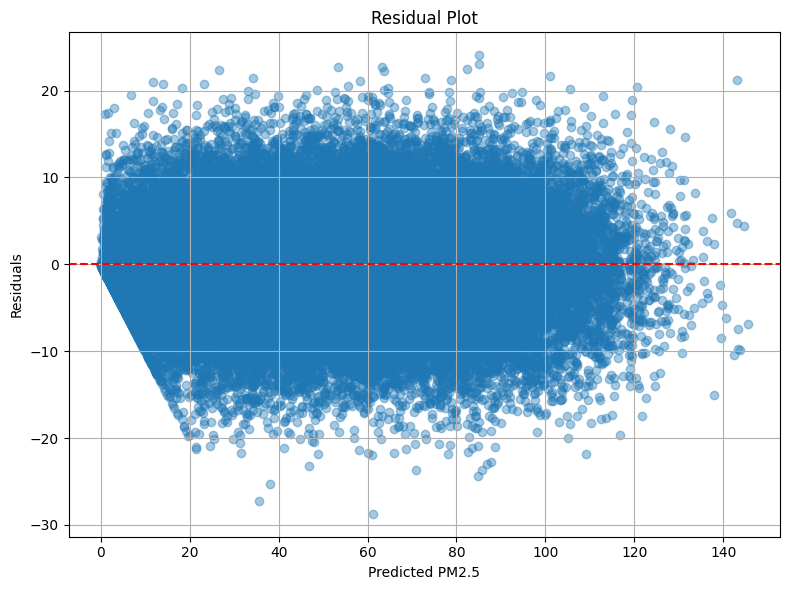

In [25]:
residuals = y_test - rf_pred

plt.figure(figsize=(8,6))
plt.scatter(rf_pred, residuals, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted PM2.5")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
save_fig("residual_plot")

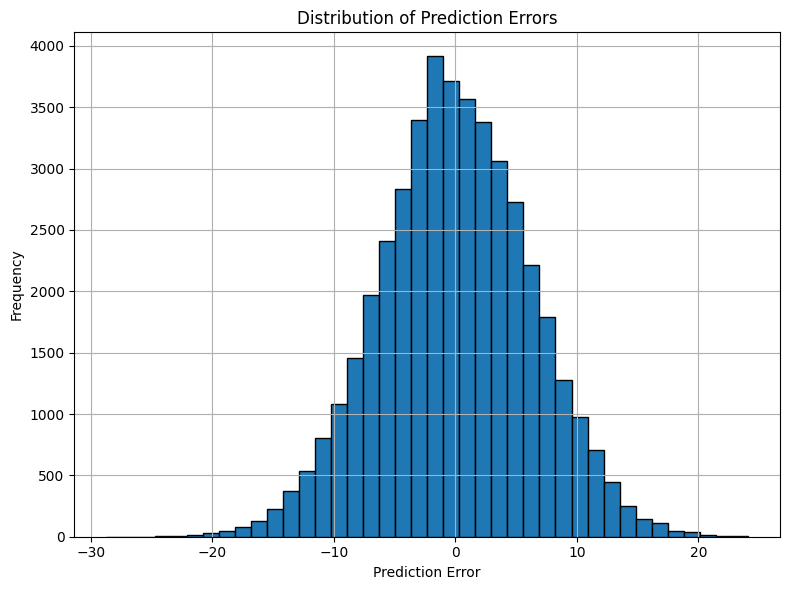

In [26]:
plt.figure(figsize=(8,6))
plt.hist(residuals, bins=40, edgecolor="black")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")
plt.grid(True)
save_fig("error_distribution")

24-hour forecast

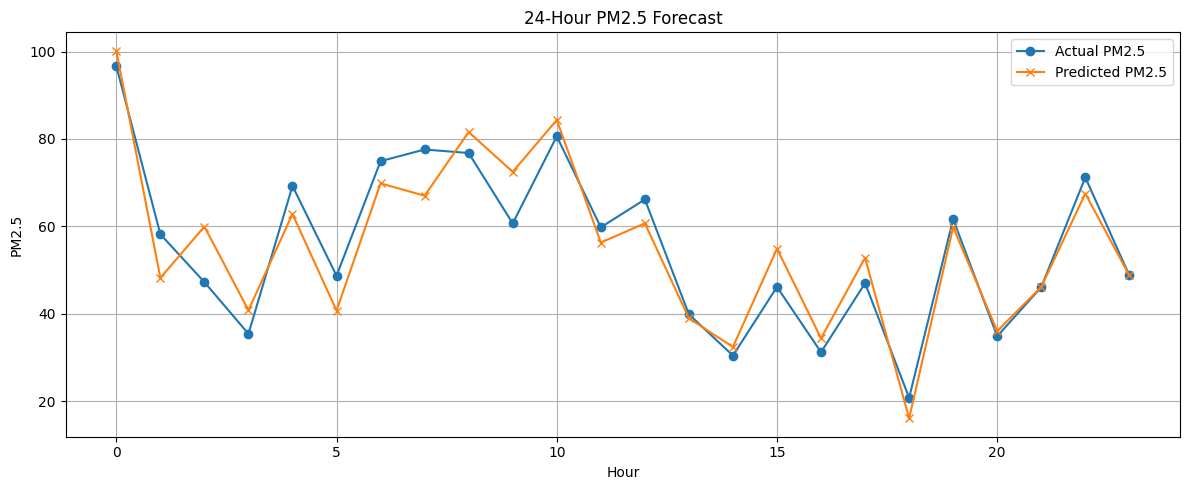

In [27]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values[:24], label="Actual PM2.5", marker="o")
plt.plot(rf_pred[:24], label="Predicted PM2.5", marker="x")
plt.title("24-Hour PM2.5 Forecast")
plt.xlabel("Hour")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(True)
save_fig("pm25_24_hour_forecast")

In [28]:
forecast = pd.DataFrame({
    "Actual_PM25": y_test.values,
    "Predicted_PM25": rf_pred
})

forecast.to_csv("pm25_forecast_results.csv", index=False)
print("Forecast results saved.")

Forecast results saved.


Save model

In [29]:
joblib.dump(rf_model, "best_pm25_model.pkl")
print("Model saved successfully.")

Model saved successfully.
